In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Introduction-

This project analyzes restaurant data from Bangalore to identify key factors influencing customer ratings. 

The dataset includes information such as restaurant location, cost, online ordering availability, table booking options, and customer votes.

The goal is to extract meaningful insights and build a machine learning model to predict restaurant ratings.

Problem Statement-

The objective of this project is to:

- Analyze restaurant data to identify trends and patterns
- Understand factors affecting customer ratings
- Build a predictive model to estimate restaurant ratings

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Loading dataset into the program
df = pd.read_csv('/kaggle/input/datasets/amangoswami001/zomato-csv/zomato.csv')
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [6]:
#Understanding the dataset
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

Data Cleaning

The dataset contained several inconsistencies and missing values.

Steps performed:

- Removed null values and duplicate records
- Cleaned the `rate` column by extracting numerical values
- Converted cost column to numeric format
- Removed irrelevant columns such as URLs and reviews
- Converted categorical variables (online order, table booking) into numerical form

These steps ensured the dataset was suitable for analysis and modeling.

In [ ]:
#Cleaning ratings
df = df[df['rate'] != 'NEW']
df = df[df['rate'] != '-']
df['rate'] = df['rate'].apply(lambda x: str(x).split('/')[0])
df['rate'] = df['rate'].astype(float)

#Cleaning cost column
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(float)

#Dropping unnecessary columns
df = df.drop(['url','phone','dish_liked','reviews_list'], axis=1)

#Cleaning rate column
df = df[df['rate'].notnull()]
df = df[df['rate'] != 'NEW']
df = df[df['rate'] != '-']
df['rate'] = df['rate'].apply(lambda x: x.split('/')[0])
df['rate'] = df['rate'].astype(float)

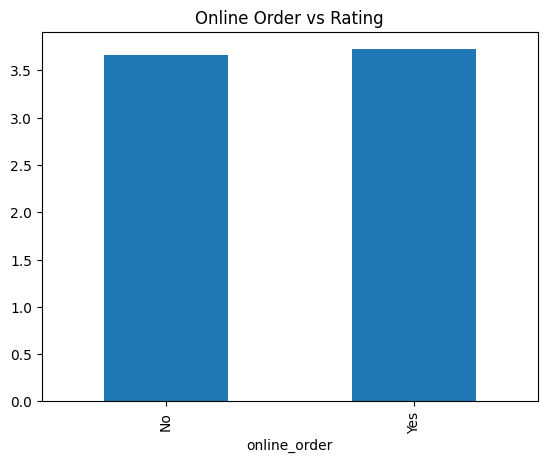

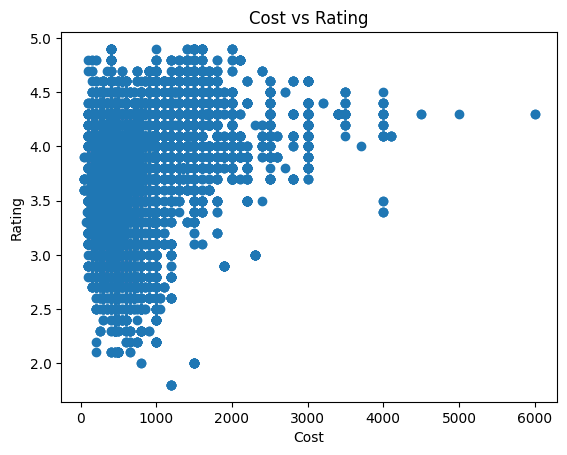

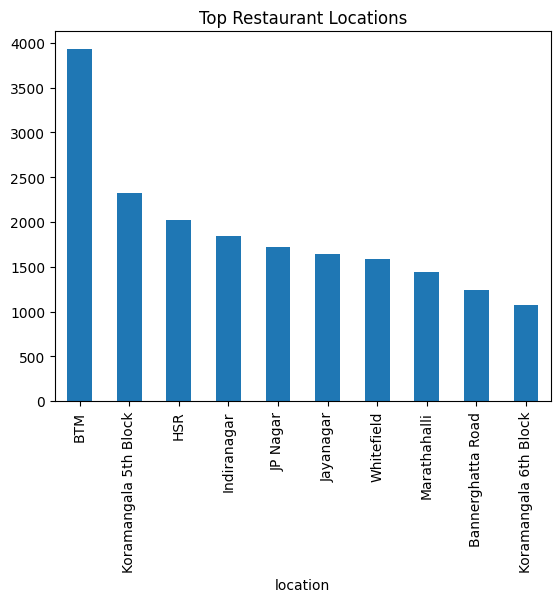

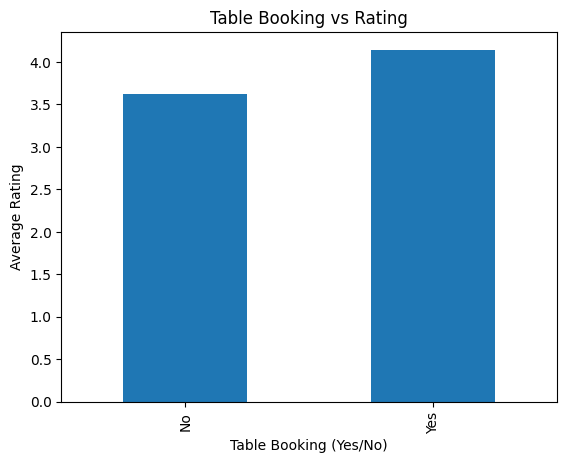

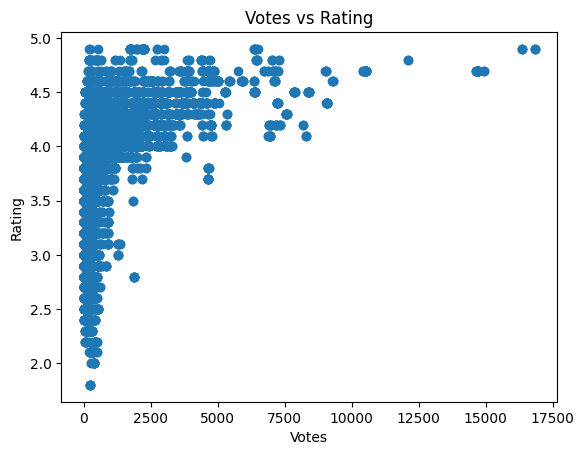

In [21]:
#Insights
# Online delivery impact
df.groupby('online_order')['rate'].mean().plot(kind='bar')
plt.title("Online Order vs Rating")
plt.show()

# Cost vs Rating
plt.scatter(df['approx_cost(for two people)'], df['rate'])
plt.xlabel("Cost")
plt.ylabel("Rating")
plt.title("Cost vs Rating")
plt.show()

# Top locations
df['location'].value_counts().head(10).plot(kind='bar')
plt.title("Top Restaurant Locations")
plt.show()

# Pre-booking impact 
table_booking_rating = df.groupby('book_table')['rate'].mean()
table_booking_rating.plot(kind='bar')
plt.title("Table Booking vs Rating")
plt.xlabel("Table Booking (Yes/No)")
plt.ylabel("Average Rating")
plt.show()

# Votes vs Rating
plt.scatter(df['votes'], df['rate'])
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.title("Votes vs Rating")
plt.show()

Q: Does online ordering affect ratings? Restaurants offering online ordering tend to have slightly higher ratings, indicating convenience may influence customer satisfaction.

Q: Relationship between cost and rating? There is no strong linear relationship between cost and rating, suggesting higher price does not guarantee better customer experience.

Q: Top locations? Most restaurants are concentrated in areas like BTM and Koramangala, indicating high competition in these regions.

Q: Do restaurants with table booking have better ratings? Restaurants offering table booking tend to have higher ratings, possibly due to better service quality and customer management.

Q: Relationship between votes and rating? Restaurants with more votes generally maintain higher ratings, suggesting that popularity and customer trust are positively correlated.

Machine Learning Model

A Linear Regression model was used to predict restaurant ratings based on selected features:

- Cost for two people
- Number of votes
- Online ordering availability

The dataset was split into training and testing sets, and the model was evaluated using performance metrics.

MAE: 0.30005092857576604
R2 Score: 0.2380665520823938


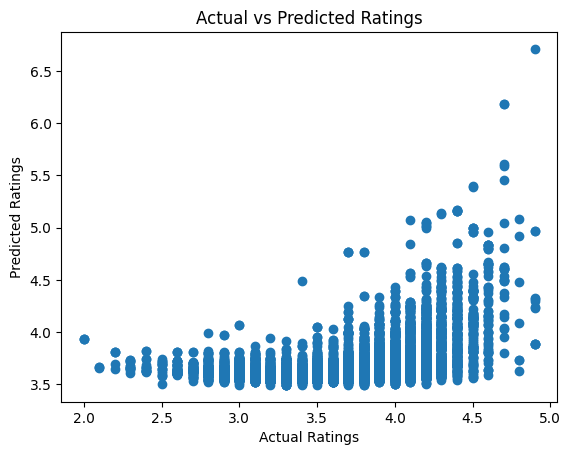

In [28]:
#ML model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Features & Target
df['online_order'] = df['online_order'].map({'Yes': 1, 'No': 0})
X = df[['approx_cost(for two people)', 'votes', 'online_order']]
X = X.fillna(0)
y = df['rate']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Visualization
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings")
plt.show()

Model performance is moderate, suggesting other hidden factors affect ratings.

Model Evaluation

The model performance was evaluated using:

- Mean Absolute Error (MAE)
- R² Score

The results indicate that while the model captures some patterns, restaurant ratings are influenced by additional factors not included in the model.

Conclusion

Key findings from this analysis:

- Online ordering and table booking positively impact ratings
- Cost does not significantly influence customer satisfaction
- Popular restaurants (with higher votes) tend to have better ratings
- Location plays a major role in restaurant distribution

The machine learning model showed moderate performance, suggesting that restaurant ratings depend on multiple complex factors such as service quality, ambiance, and customer experience.

This project demonstrates how data analysis can provide actionable insights for decision-making in the food industry.